=== RELATÓRIO DE CLASSIFICAÇÃO ===
                precision    recall  f1-score   support

Bipolar Type-1       0.40      0.50      0.44         4
Bipolar Type-2       0.80      0.80      0.80         5
    Depression       0.78      0.88      0.82         8
        Normal       0.80      0.57      0.67         7

      accuracy                           0.71        24
     macro avg       0.69      0.69      0.68        24
  weighted avg       0.73      0.71      0.71        24



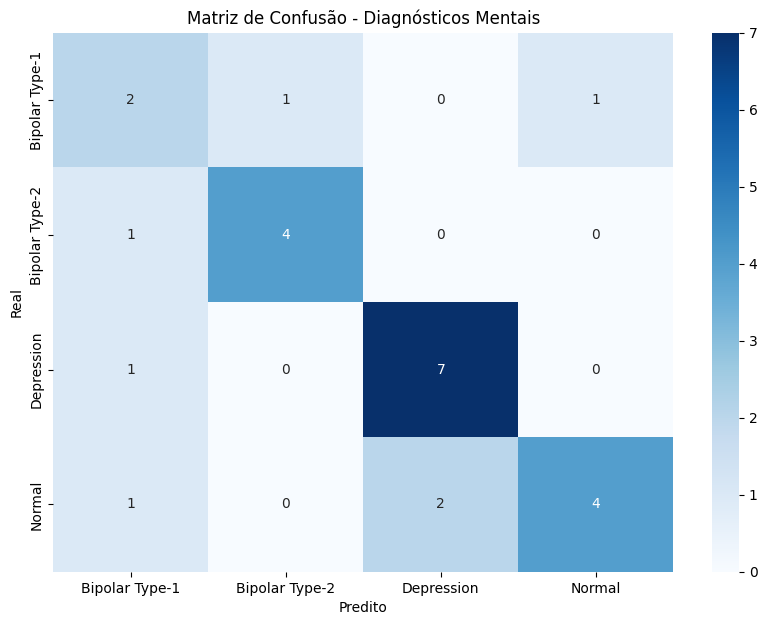

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar os dados
# O nome do arquivo no Kaggle costuma ser este:
df = pd.read_csv('../data/Dataset-Mental-Disorders.csv')

# 2. Limpeza Essencial
# Esse dataset específico tem uma coluna de ID e uma de 'Expert Diagnose'
# Vamos remover o ID e usar o Expert Diagnose como alvo (y)
X = df.drop(['Patient Number', 'Expert Diagnose'], axis=1)
y = df['Expert Diagnose']

# 3. Transformar texto em números (Label Encoding)
# Modelos de ML não entendem "Yes/No" ou "Bipolar", apenas números.
le = LabelEncoder()

# Transformamos todas as colunas de sintomas
for col in X.columns:
    X[col] = le.fit_transform(X[col])

# Transformamos o diagnóstico alvo
y = le.fit_transform(y)
target_names = le.classes_

# 4. Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Modelo (Random Forest - O queridinho para dados estruturados)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 6. Predição e Resultados
y_pred = modelo.predict(X_test)

print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred, target_names=target_names))

# 7. Visualização (Diferencial de TCC)
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
            xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Diagnósticos Mentais')
plt.show()